# Codificación clínica CIE-10 con recuperación + LLM: análisis

Cuaderno de lectura del estudio. Todos los números salen de los archivos de
`resultados/`; las corridas contra la API están en los scripts de `src/`.

**Resultado principal:** en CodiEsp-D, `gpt-4o-mini` + recuperación llega a **MAP 0,090**
en test (categoría de 3 caracteres: 0,267). El mejor sistema supervisado del shared task
de 2020 llegó a 0,593.

In [1]:
import json, pandas as pd
from pathlib import Path
RES = Path("..") / "resultados"
FIG = Path("..") / "figuras"
pd.set_option("display.max_colwidth", 90)

## 1. El corpus (Bloque A)

In [2]:
print((RES / "eda_bloque_a.md").read_text())

# EDA Bloque A - CodiEsp subtrack D (diagnósticos)

## Casos y códigos por split

| split | casos | filas gold | códigos/caso (media) | mediana | min | max |
|---|---|---|---|---|---|---|
| train | 500 | 5639 | 11.3 | 10 | 1 | 40 |
| dev | 250 | 2677 | 10.7 | 10 | 1 | 33 |
| test | 250 | 2842 | 11.4 | 10 | 1 | 35 |

## Longitud de los casos (palabras)

| split | media | p10 | p50 | p90 | max |
|---|---|---|---|---|---|
| train | 349 | 164 | 314 | 576 | 1172 |
| dev | 352 | 173 | 328 | 570 | 956 |
| test | 353 | 161 | 330 | 555 | 965 |

## Diccionario CIE-10-ES (subtrack D)

- Códigos en el diccionario: 98,288

### Cobertura del gold por el diccionario

| split | códigos únicos gold | en diccionario | fuera | cobertura |
|---|---|---|---|---|
| train | 1767 | 1767 | 0 | 100.0% |
| dev | 1158 | 1158 | 0 | 100.0% |
| test | 1143 | 1143 | 0 | 100.0% |

Todos los códigos gold están en el diccionario.

## Códigos de dev/test ya vistos en train

| split | códigos únicos | también en train | s

## 2. La recuperación tiene un techo (Bloque B)

Consultar con el caso completo fracasa. Por frases y con fusión denso + BM25 sube, pero
la unión de todos los candidatos solo cubre el 52% del gold: el 65% de lo que falta son
códigos vagos sin anclaje textual.

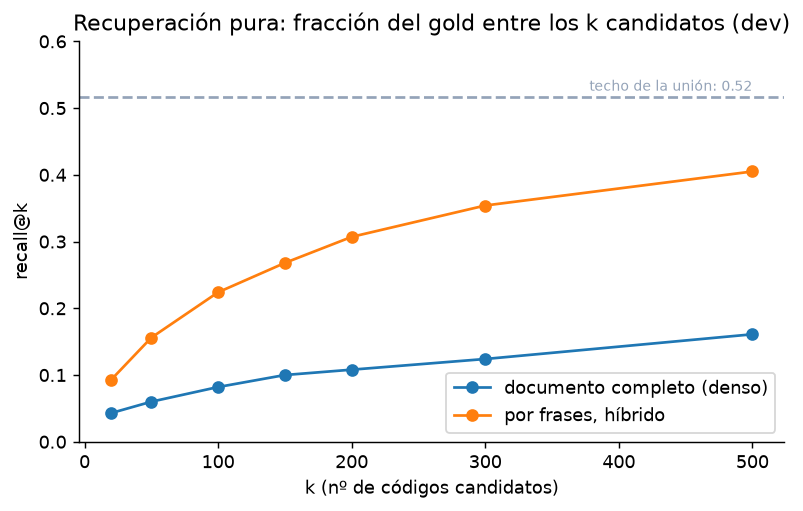

# Recuperación pura - recall@k (split dev)

Embeddings: text-embedding-3-small dim 512. 250 casos, 15.6 frases/caso, 10.7 códigos/caso.

recall@k = fracción de códigos gold del caso presentes entre los k candidatos, promediada sobre casos.

| estrategia | r@20 | r@50 | r@100 | r@150 | r@200 | r@300 | r@500 |
|---|---|---|---|---|---|---|---|
| doc-denso | 0.043 | 0.060 | 0.082 | 0.100 | 0.108 | 0.124 | 0.161 |
| frase-denso (kf=30) | 0.049 | 0.098 | 0.160 | 0.188 | 0.212 | 0.242 | 0.264 |
| frase-hibrido (kf=30) | 0.093 | 0.156 | 0.224 | 0.268 | 0.307 | 0.354 | 0.405 |
| frase-denso (kf=50) | 0.043 | 0.080 | 0.133 | 0.174 | 0.207 | 0.243 | 0.292 |
| frase-hibrido (kf=50) | 0.082 | 0.140 | 0.202 | 0.251 | 0.284 | 0.337 | 0.403 |
| TECHO union (kf=50, sin cap) | 0.516 | 0.516 | 0.516 | 0.516 | 0.516 | 0.516 | 0.516 |

## Análisis

- **La consulta por documento completo fracasa** (recall@200 = 0.11). Un caso tiene
  ~11 diagnósticos distintos y un solo embedding no los representa.
- **Con

In [3]:
from IPython.display import Image, display
display(Image(str(FIG / "fig_recall_retrieval.png")))
print((RES / "eval_retrieval_dev.md").read_text())

## 3. El codificador y los ablations (Bloques C y D)

In [4]:
filas = [json.loads(l) for l in (RES / "eval_codificador.jsonl").read_text().splitlines() if l.strip()]
df = pd.DataFrame(filas)[["config","n","MAP","MAP_cat3","F1_micro","P","R",
                          "cods_pred/caso","alucinac/caso","costo_1000casos_usd"]]
df

,config,n,MAP,MAP_cat3,F1_micro,P,R,cods_pred/caso,alucinac/caso,costo_1000casos_usd
0,gpt-4o-mini_concand,40,0.124,0.313,0.159,0.149,0.203,13.9,0.03,0.79
1,gpt-4o_concand,30,0.230,0.413,0.305,0.344,0.318,8.0,0.03,11.34
2,gpt-4o-mini_concand,100,0.098,0.290,0.145,0.138,0.178,14.4,0.05,0.83
3,gpt-4o-mini_sincand,100,0.097,0.250,0.154,0.158,0.164,12.7,0.39,0.37
4,gpt-4o-mini_concand_fewshot,100,0.096,0.285,0.160,0.174,0.165,10.9,0.04,0.91
5,gpt-4o-mini_concand_pmin,100,0.069,0.228,0.133,0.219,0.105,6.0,0.01,0.62
6,gpt-4o-mini_concand,250,0.092,0.274,0.130,0.118,0.175,14.4,0.03,0.83
7,gpt-4o-mini_concand,250,0.090,0.267,0.134,0.126,0.171,14.2,0.06,0.82
8,gpt-4o_concand,50,0.196,0.366,0.281,0.322,0.281,8.5,0.04,15.77


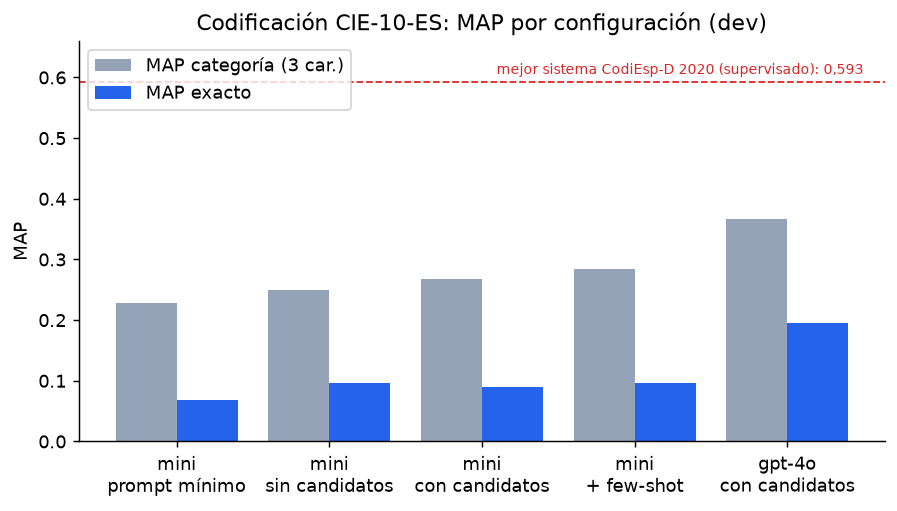

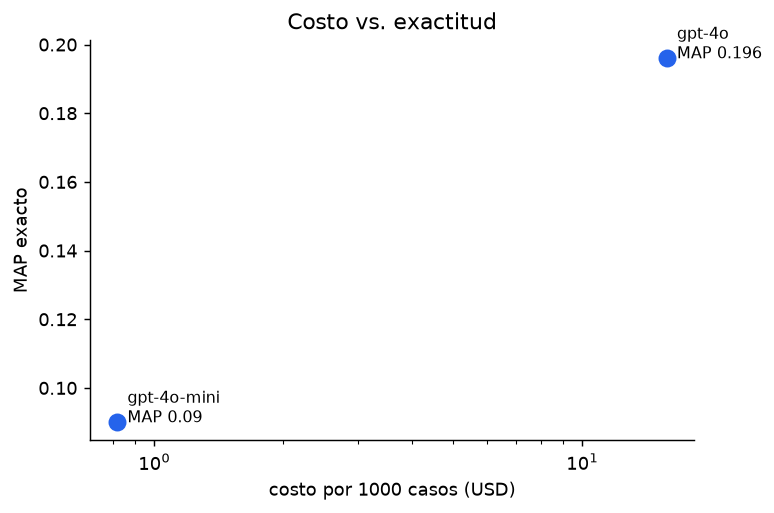

In [5]:
display(Image(str(FIG / "fig_map_por_config.png")))
display(Image(str(FIG / "fig_costo_map.png")))

Lecturas:

- **Candidatos vs. sin candidatos:** el MAP exacto casi no cambia, pero la alucinación
  de códigos cae de 0,39 a 0,05 por caso. La recuperación ancla, no mejora la exactitud.
- **Prompt exhaustivo vs. mínimo:** el mínimo predice 6 códigos por caso (el gold tiene
  ~13) y el MAP baja a 0,069.
- **Few-shot:** neutro.
- **gpt-4o vs. gpt-4o-mini:** dobla el MAP, a ~19x el costo por caso.

## 4. Análisis de errores

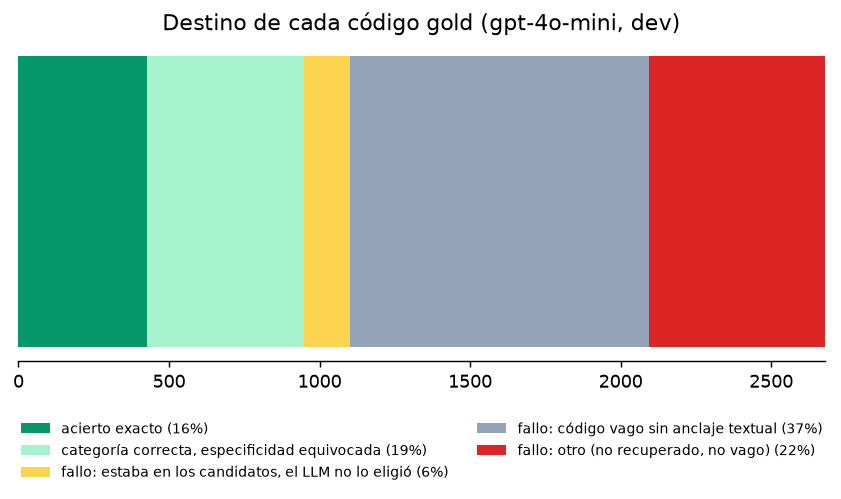

# Análisis de errores - gpt-4o-mini_concand (dev, 250 casos)

2677 códigos gold, 3588 predichos.

## Destino de cada código GOLD

| categoría | n | % |
|---|---|---|
| acierto exacto | 427 | 16.0% |
| categoría correcta, especificidad equivocada | 522 | 19.5% |
| fallo: estaba en los candidatos, el LLM no lo eligió | 152 | 5.7% |
| fallo: código vago sin anclaje textual | 993 | 37.1% |
| fallo: otro (no recuperado, no vago) | 583 | 21.8% |

## Destino de cada código PREDICHO

| categoría | n | % |
|---|---|---|
| correcto (exacto) | 427 | 11.9% |
| categoría correcta, especificidad equivocada | 682 | 19.0% |
| sobrecodificación (ni exacto ni categoría) | 2479 | 69.1% |

## Ejemplos de gold no acertado

- `q62.11` Oclusión congénita de la unión pieloureteral (estaba en candidatos) — S0004-06142005000900016-1
- `n28.0` Isquemia e infarto del riñón (no recuperado) — S0004-06142005000900016-1
- `n20.0` Cálculo del riñón (no recuperado) — S0004-06142005000900016-1
- `n02.1` Hematuria recidi

In [6]:
display(Image(str(FIG / "fig_destino_gold.png")))
print((RES / "analisis_errores_gpt-4o-mini_concand.md").read_text())

## 5. Conclusión

Un LLM genérico sin entrenar queda lejos del estado del arte supervisado en
codificación exhaustiva CIE-10-ES, y la brecha es estructural, no de "más datos":

1. La recuperación sobre descripciones no puede pasar de ~0,52 de recall.
2. El 37% del gold son códigos administrativos vagos sin anclaje textual.
3. La mitad de los fallos clínicos son de especificidad (categoría correcta, dígito
   equivocado): a nivel de 3 caracteres el acierto casi se duplica.

Como apoyo acotado, con validación encima y sobre la parte nombrable del diagnóstico, la
herramienta sí tiene dónde aportar. Ese es el punto de partida de las fases siguientes.